In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_csv("/content/twitter_training.csv")

ParserError: Error tokenizing data. C error: EOF inside string starting at row 31868

In [ ]:
import pandas as pd
import numpy as np

# Specify the 'quoting' parameter to handle potential quoting issues.
# quoting=3 (csv.QUOTE_NONE) tells pandas to ignore quotes.
# You might need to experiment with other quoting options like:
# - csv.QUOTE_ALL (0): quote all fields
# - csv.QUOTE_MINIMAL (1): quote only fields containing special characters
# - csv.QUOTE_NONNUMERIC (2): quote all non-numeric fields

try:
    data = pd.read_csv("/content/twitter_training.csv", quoting=3, on_bad_lines='skip')
except pd.errors.ParserError as e:
    print(f"An error occurred while reading the CSV: {e}")
    # Handle the error, e.g., investigate problematic lines or adjust quoting options.

# The 'on_bad_lines='skip'' argument skips problematic lines that cause errors,
# allowing you to proceed with reading the rest of the file.
# Use it cautiously as it results in data loss.

In [ ]:
data.head(10)

,2401,Borderlands,Positive,"""im getting on borderlands and i will murder you all",""""
0,2401,Borderlands,Positive,"""I am coming to the borders and I will kill yo...",""""
1,2401,Borderlands,Positive,"""im getting on borderlands and i will kill you...",""""
2,2401,Borderlands,Positive,"""im coming on borderlands and i will murder yo...",""""
3,2401,Borderlands,Positive,"""im getting on borderlands 2 and i will murder...",""""
4,2401,Borderlands,Positive,"""im getting into borderlands and i can murder ...",""""
5,2402,Borderlands,Positive,So I spent a few hours making something for fu...,NaN
6,2402,Borderlands,Positive,"""So I spent a couple of hours doing something ...",I decided to make a wallpaper for my PC.. Her...
7,2402,Borderlands,Positive,So I spent a few hours doing something for fun...,NaN
8,2402,Borderlands,Positive,So I spent a few hours making something for fu...,NaN
9,2402,Borderlands,Positive,2010 So I spent a few hours making something f...,NaN


In [ ]:
data.shape

(67774, 5)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67774 entries, 0 to 67773
Data columns (total 5 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   67774 non-null  int64 
 1   Borderlands                                            67774 non-null  object
 2   Positive                                               67774 non-null  object
 3   "im getting on borderlands and i will murder you all   67088 non-null  object
 4   "                                                      12088 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.6+ MB


In [ ]:
data.describe()

,2401
count,67774.000000
mean,6429.943282
std,3740.947129
min,1.000000
25%,3161.250000
50%,6456.000000
75%,9604.000000
max,13200.000000


In [ ]:
data.columns

Index(['2401', 'Borderlands', 'Positive',
       '"im getting on borderlands and i will murder you all ', '"'],
      dtype='object')

In [ ]:

df= data.drop('"',axis=1,inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67774 entries, 0 to 67773
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   67774 non-null  int64 
 1   Borderlands                                            67774 non-null  object
 2   Positive                                               67774 non-null  object
 3   "im getting on borderlands and i will murder you all   67088 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [ ]:
data.head()

,2401,Borderlands,Positive,"""im getting on borderlands and i will murder you all"
0,2401,Borderlands,Positive,"""I am coming to the borders and I will kill yo..."
1,2401,Borderlands,Positive,"""im getting on borderlands and i will kill you..."
2,2401,Borderlands,Positive,"""im coming on borderlands and i will murder yo..."
3,2401,Borderlands,Positive,"""im getting on borderlands 2 and i will murder..."
4,2401,Borderlands,Positive,"""im getting into borderlands and i can murder ..."


In [ ]:
columns = ['id','land','Label','Text']

,2401,Borderlands,Positive,"""im getting on borderlands and i will murder you all"
0,2401,Borderlands,Positive,"""I am coming to the borders and I will kill yo..."
1,2401,Borderlands,Positive,"""im getting on borderlands and i will kill you..."
2,2401,Borderlands,Positive,"""im coming on borderlands and i will murder yo..."
3,2401,Borderlands,Positive,"""im getting on borderlands 2 and i will murder..."
4,2401,Borderlands,Positive,"""im getting into borderlands and i can murder ..."


In [ ]:
data.rename(columns={'2401': 'id', 'Borderlands': 'land', 'Positive': 'Sentiment'}, inplace=True)

In [ ]:
data.head()

,id,land,Sentiment,"""im getting on borderlands and i will murder you all"
0,2401,Borderlands,Positive,"""I am coming to the borders and I will kill yo..."
1,2401,Borderlands,Positive,"""im getting on borderlands and i will kill you..."
2,2401,Borderlands,Positive,"""im coming on borderlands and i will murder yo..."
3,2401,Borderlands,Positive,"""im getting on borderlands 2 and i will murder..."
4,2401,Borderlands,Positive,"""im getting into borderlands and i can murder ..."


In [ ]:
data.rename(columns={data.columns[-1]: 'text'}, inplace=True)

In [ ]:
data.head()

,id,land,Sentiment,text
0,2401,Borderlands,Positive,"""I am coming to the borders and I will kill yo..."
1,2401,Borderlands,Positive,"""im getting on borderlands and i will kill you..."
2,2401,Borderlands,Positive,"""im coming on borderlands and i will murder yo..."
3,2401,Borderlands,Positive,"""im getting on borderlands 2 and i will murder..."
4,2401,Borderlands,Positive,"""im getting into borderlands and i can murder ..."


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.isnull().sum()

,0
id,0
land,0
Sentiment,0
text,0


In [ ]:
data.duplicated().sum()

3759

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

0

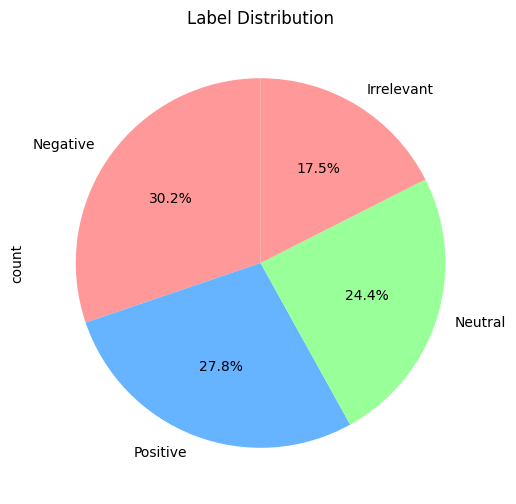

In [ ]:
import matplotlib.pyplot as plt
label_counts = data['Sentiment'].value_counts()

plt.figure(figsize=(6, 6))
label_counts.plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
plt.title("Label Distribution")

plt.show()

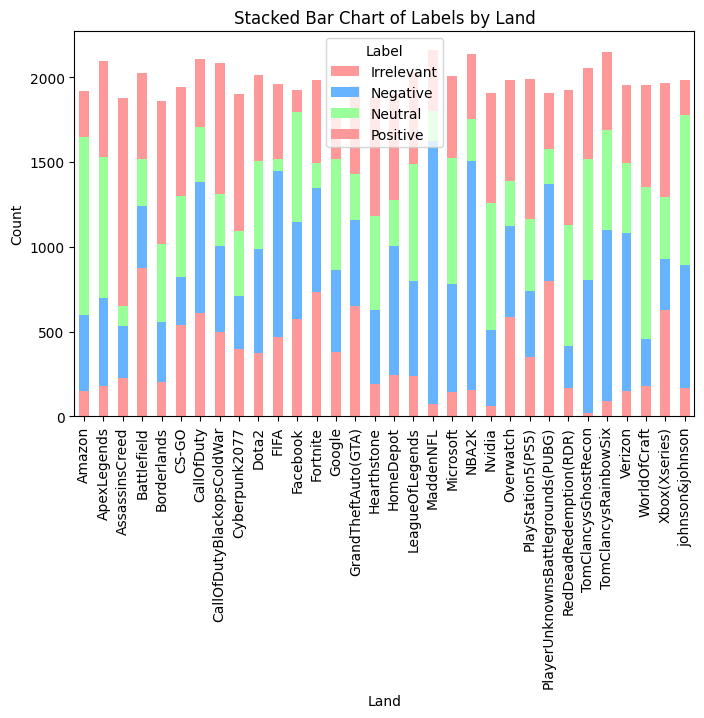

In [ ]:
land_label_counts = data.groupby(['land', 'Sentiment']).size().unstack(fill_value=0)

# Plot
land_label_counts.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Stacked Bar Chart of Labels by Land")
plt.xlabel("Land")
plt.ylabel("Count")
plt.legend(title="Label")
plt.show()

In [ ]:
import string
import numpy as np
import re
import unicodedata
import html
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.layers import SimpleRNN, Embedding,Dense,LSTM, Dropout,GRU,Bidirectional
import subprocess
import emoji
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
import warnings
warnings.filterwarnings('ignore')
import nltk
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.9/586.9 kB 10.4 MB/s eta 0:00:00


In [ ]:
X=data['text']
y=data['Sentiment'].map({'Neutral': 1, 'Negative': 0,'Positive':2,'Irrelevant':3})

In [ ]:
def normalize_text(text):
    # Initialize lemmatizer and tokenizer
    lemmatizer = WordNetLemmatizer()
    tokenizer = TweetTokenizer()

    stop_words = set(stopwords.words('english')) - {'not', 'no', 'never', 'nor', 'none', 'nothing', 'neither'}

    # Replace HTML entities and special characters
    text = text.lower().replace('#39;', "'").replace('amp;', '&').replace('#146;', "'") \
        .replace('nbsp;', ' ').replace('#36;', '$').replace('\\n', "\n").replace('quot;', "'") \
        .replace('<br />', "\n").replace('\\"', '"').replace('<unk>', 'u_n').replace(' @.@ ', '.') \
        .replace(' @-@ ', '-').replace('\\', ' \\ ')
    text = re.sub(r'  +', ' ', html.unescape(text))
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove emails
    text = re.sub(r'\S+@\S+\.\S+', '', text)

    # Map emojis to their textual equivalents
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove non-ASCII characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

   # Tokenize the text
    words = tokenizer.tokenize(text)

    # Remove stopwords (excluding negations)
    words = [word for word in words if word not in stop_words]

    # Lemmatize words (preserve sentiment-bearing words)
    words = [lemmatizer.lemmatize(word, pos='v') for word in words]

    # Retain exclamation marks and question marks for tone
    words = [word for word in words if word not in string.punctuation or word in {'!', '?'}]

    return ' '.join(words)

In [ ]:
X=X.apply(normalize_text)
X.head()

,text
0,come border kill
1,im get borderlands kill
2,im come borderlands murder
3,im get borderlands 2 murder
4,im get borderlands murder


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50663,), (12666,), (50663,), (12666,))

In [ ]:
# Import necessary libraries
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

# Assuming you have already preprocessed your data and have X and y defined
# X = data['text'] (raw text)
# y = data['Sentiment'].map({'Neutral': 1, 'Negative': 0, 'Positive': 2, 'Irrelevant': 1})

# Preprocess the text data
X_cleaned = X.apply(normalize_text)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.2, random_state=42)

# Create a pipeline with TF-IDF Vectorizer and Multinomial Naive Bayes
pipeline = make_pipeline(TfidfVectorizer(), MultinomialNB())

#Define the parameter grid
param_grid = {
    'tfidfvectorizer__ngram_range': [(1, 1), (1, 2)],  # Unigrams or unigrams + bigrams
    'tfidfvectorizer__max_df': [0.9, 0.95],            # Ignore terms with higher document frequency
    'tfidfvectorizer__min_df': [1, 2],                 # Ignore terms appearing in fewer documents
    'tfidfvectorizer__max_features': [None, 5000, 10000],  # Limit the number of features
    'multinomialnb__alpha': [0.1, 0.5, 1.0, 2.0]       # Smoothing parameter for Naive Bayes
}

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Get the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Evaluate on the test set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Tuned Model Accuracy:", accuracy)

print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters: {'multinomialnb__alpha': 0.1, 'tfidfvectorizer__max_df': 0.9, 'tfidfvectorizer__max_features': None, 'tfidfvectorizer__min_df': 1, 'tfidfvectorizer__ngram_range': (1, 2)}
Tuned Model Accuracy: 0.900126322438023
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      3751
           1       0.94      0.88      0.91      3096
           2       0.89      0.90      0.90      3581
           3       0.95      0.85      0.90      2238

    accuracy                           0.90     12666
   macro avg       0.91      0.89      0.90     12666
weighted avg       0.90      0.90      0.90     12666



In [ ]:
# Function to predict sentiment from user input
def predict_sentiment(user_input, trained_pipeline): # Pass the trained pipeline as an argument
    # Preprocess the user input
    cleaned_input = normalize_text(user_input)

    # Use the trained model to predict the sentiment
    prediction = trained_pipeline.predict([cleaned_input])  # Use the passed pipeline

    # Map the prediction to the corresponding sentiment label
    sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive', 3: 'Irrelevant'}
    predicted_sentiment = sentiment_map[prediction[0]]

    return predicted_sentiment

# Main loop for user input
def main():
    inputs = []

    # Pass the trained pipeline to predict_sentiment
    while True:
        user_input = input("Please enter your text (or type 'exit' to quit): ")

        if user_input.lower() == 'exit':
            break

        inputs.append(user_input)
        # Use best_model (from GridSearchCV) for prediction
        predicted_sentiment = predict_sentiment(user_input, best_model) # Pass the best_model object instead of the original pipeline
        print(f"The predicted sentiment is: {predicted_sentiment}")

    print("You entered the following inputs:")
    for i in inputs:
        print(i)

# Example usage
if __name__ == "__main__":
    main()

Please enter your text (or type 'exit' to quit): hi
The predicted sentiment is: Negative
Please enter your text (or type 'exit' to quit): this is the worst experience
The predicted sentiment is: Negative
Please enter your text (or type 'exit' to quit): i just loved this product
The predicted sentiment is: Positive
Please enter your text (or type 'exit' to quit): what are you saying?
The predicted sentiment is: Negative
Please enter your text (or type 'exit' to quit): it is very nice
The predicted sentiment is: Positive
Please enter your text (or type 'exit' to quit): just living like a pro
The predicted sentiment is: Neutral
Please enter your text (or type 'exit' to quit): i have an issue with you
The predicted sentiment is: Negative
Please enter your text (or type 'exit' to quit): you are fantastic
The predicted sentiment is: Positive
Please enter your text (or type 'exit' to quit): but you are saying that you do not go there but you are happy without going there
The predicted sentime